# Mini Project 1: Monte Carlo Notebook for European Payoff

## $\textbf{Section 1: European Option Pricing via Monte Carlo Simulation}$

In this section, we implement a Monte Carlo engine to price a European Call Option. To ensure maximum efficiency, we use the Box-Muller transform to generate standard normal variables manually, avoiding the overhead of high-level libraries. The core logic is optimized using Numba's Just-In-Time (JIT) compilation, allowing us to simulate millions of paths in a fraction of a second. We also calculate the 95% confidence interval to quantify the simulation's statistical error.

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import time
from numba import njit

@njit
def normal_generator(N):
    """
    Generates standard normal random variables using the Box-Muller transform.
    Optimized with Numba (JIT) for high-performance computing.
    """
    U1 = np.random.uniform(0, 1, N) 
    U2 = np.random.uniform(0, 1, N)
    Z0 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2) 
    Z1 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    return Z0, Z1

def european_option_pricer(S0, K, T, r, sigma, N):
    """
    Calculates the terminal price (ST), payoffs, discounted expected value, 
    and the 95% confidence interval error for a European Call Option.
    """
    Z0, _ = normal_generator(N)
    
    # Simulate terminal stock prices using Geometric Brownian Motion
    price = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z0)
    
    # Calculate payoffs for a Call Option
    payoffs = np.maximum(price - K, 0)
    
    # Monte Carlo Estimator
    expected_payoff = np.mean(payoffs)
    option_value = np.exp(-r * T) * expected_payoff
    
    # Standard Error Calculation (95% Confidence Interval)
    # Using the standard deviation of payoffs for the Monte Carlo error
    std_payoff = np.std(payoffs)
    err = 1.96 * np.exp(-r * T) * std_payoff / np.sqrt(N)
    
    return price, payoffs, option_value, err

Execution Time: 0.0735 seconds


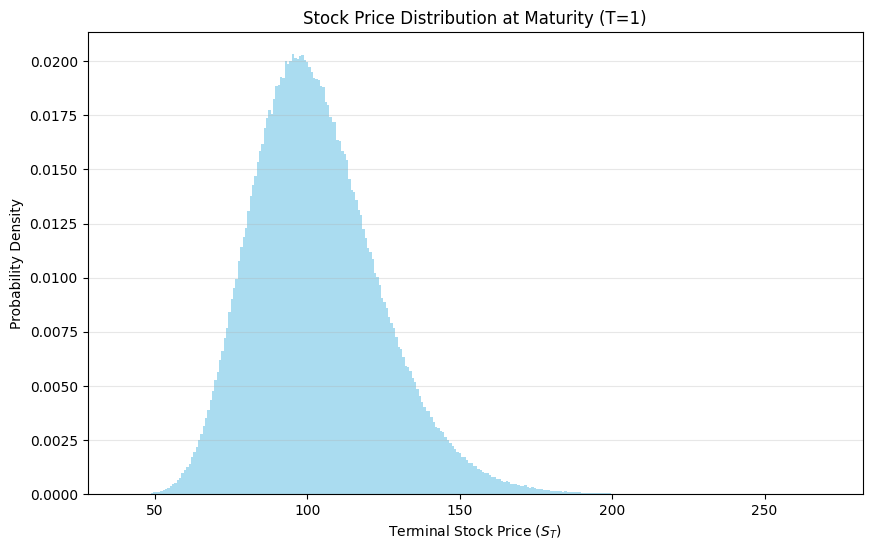

The estimated option price is: 7.14 +/- 0.02464 EUR


In [5]:
# --- Simulation Execution ---
t0 = time.perf_counter()
# Simulating 1,000,000 paths
price, payoffs, V, err = european_option_pricer(100, 105, 1, 0.03, 0.2, 1000000)
t1 = time.perf_counter()

print(f"Execution Time: {t1 - t0:.4f} seconds")

# --- Visualisation ---
plt.figure(figsize=(10, 6))
plt.hist(price, bins=300, density=True, color='skyblue', alpha=0.7)
plt.title('Stock Price Distribution at Maturity (T=1)')
plt.xlabel('Terminal Stock Price ($S_T$)')
plt.ylabel('Probability Density')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"The estimated option price is: {V:.2f} +/- {err:.5f} EUR")

## $\textbf{Section 2: Simulating Asset Price Paths (Geometric Brownian Motion)}$

Beyond terminal pricing, it is essential to visualize the evolution of the underlying asset. Here, we discretize the Geometric Brownian Motion (GBM) stochastic differential equation using daily steps ($dt = 1/252$). By simulating multiple paths, we can observe the "drift" (expected return) and "volatility" (risk) in action, providing a visual representation of the uncertainty inherent in financial markets.

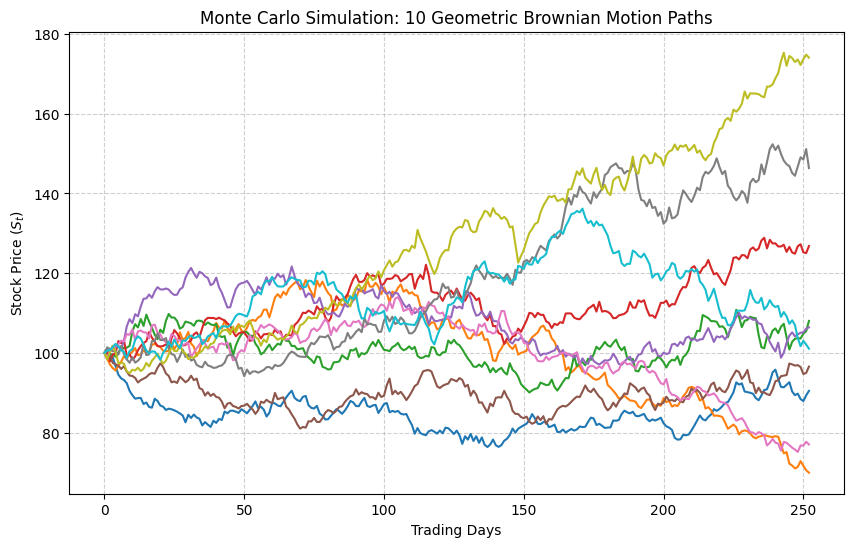

In [3]:
# --- Simulation Parameters ---
S0 = 100          # Initial stock price
r = 0.03          # Risk-free rate (drift)
sigma = 0.2       # Volatility (annualized)
T = 1             # Time to maturity (1 year)
n_steps = 252     # Trading days in a year
n_sims = 10       # Number of paths to visualize
dt = T / n_steps  # Time step increment

# 1. Generate standard normal random shocks
Z = np.random.standard_normal((n_steps, n_sims))

# 2. Calculate log-returns for each step using Geometric Brownian Motion (GBM)
# Discretization: (r - 0.5 * sigma^2) * dt + sigma * sqrt(dt) * Z
log_returns = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z

# 3. Accumulate returns: In log-space, a sum of returns equals a product of price factors
log_paths = np.cumsum(log_returns, axis=0)

# 4. Convert back to price levels and prepend the starting price S0
S = S0 * np.exp(log_paths)
S = np.vstack([np.full(n_sims, S0), S])

# --- Plotting the Asset Price Paths ---
plt.figure(figsize=(10, 6))
plt.plot(S)
plt.title(f"Monte Carlo Simulation: {n_sims} Geometric Brownian Motion Paths")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($S_t$)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## $\textbf{Section 3: Algorithmic Strategy Backtesting (SMA20)}$

Finally, we implement a trend-following strategy based on a 20-day Simple Moving Average (SMA). This section demonstrates the use of Pandas for vectorized financial analysis. A critical aspect of this implementation is the use of .shift(1) on our signals to prevent look-ahead bias, ensuring that today’s trades are only based on information available yesterday. We conclude by comparing the strategy's cumulative return against a "Buy & Hold" benchmark.

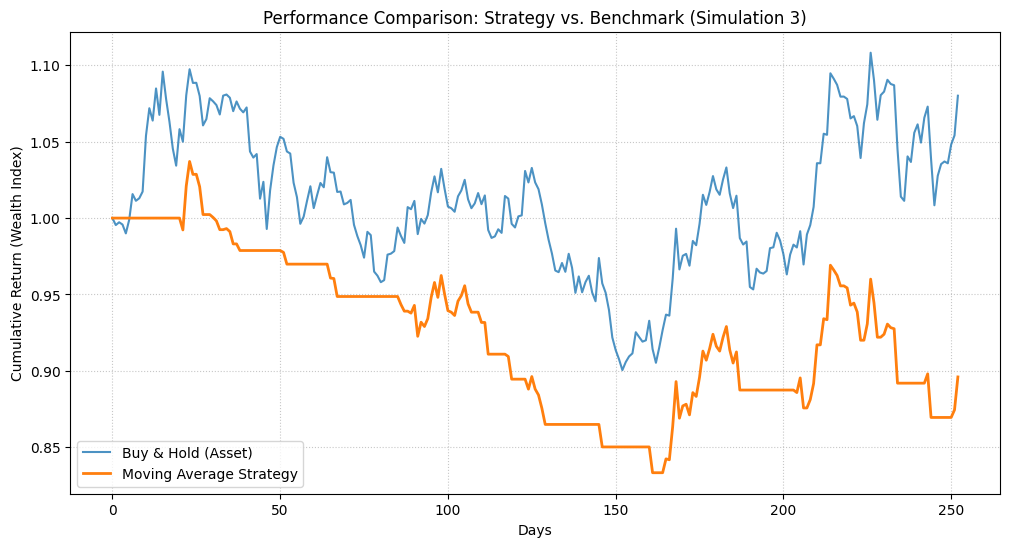

Final Asset Return: 1.080
Final Strategy Return: 0.896
Total Trading Signals: 108 (Approx. once every 2.3 days)


In [12]:
# --- Strategy Setup & Dataframe Creation ---
columns = [f'Simulation {i+1}' for i in range(n_sims)]
df = pd.DataFrame(S, columns=columns)

# We choose 'Simulation 1' for our analysis
target_sim = 'Simulation 3'

# Calculate the 20-day Simple Moving Average (SMA)
df['SMA20'] = df[target_sim].rolling(window=20).mean()

# Trading Signal: 1 if price is above SMA20, 0 otherwise
df['Signal'] = (df[target_sim] > df['SMA20']).astype(int)

# --- Backtesting Logic ---

# 1. Calculate Daily Asset Returns (Benchmark)
df['Asset_Returns'] = df[target_sim].pct_change()

# 2. Apply the previous day's signal to TODAY'S return
# This is crucial to avoid "Look-ahead bias"
df['Strategy_Returns'] = df['Signal'].shift(1) * df['Asset_Returns']

# 3. Calculate Cumulative Returns (Wealth Index)
# Adding 1 converts returns to growth factors; cumprod() accounts for compound interest
df['Cumulative_Strategy_Return'] = (1 + df['Strategy_Returns'].fillna(0)).cumprod()
df['Cumulative_Asset_Return'] = (1 + df['Asset_Returns'].fillna(0)).cumprod()

# --- Visualization ---
plt.figure(figsize=(12, 6))
plt.plot(df['Cumulative_Asset_Return'], label='Buy & Hold (Asset)', alpha=0.8)
plt.plot(df['Cumulative_Strategy_Return'], label='Moving Average Strategy', linewidth=2)
plt.title(f'Performance Comparison: Strategy vs. Benchmark ({target_sim})')
plt.xlabel('Days')
plt.ylabel('Cumulative Return (Wealth Index)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

# --- Performance Metrics ---
final_asset_perf = df['Cumulative_Asset_Return'].iloc[-1]
final_strat_perf = df['Cumulative_Strategy_Return'].iloc[-1]
total_trades = df['Signal'].sum()

print(f"Final Asset Return: {final_asset_perf:.3f}")
print(f"Final Strategy Return: {final_strat_perf:.3f}")
print(f"Total Trading Signals: {total_trades} (Approx. once every {252 / total_trades:.1f} days)")

$\textbf{Key Takeaway:}$

While the SMA strategy underperformed in this specific low-volatility/positive-drift scenario, this framework provides a robust foundation for testing more complex alpha-generating signals.